<a href="https://colab.research.google.com/github/ligi-data-analytics/Financial-Loan-Portfolio-Risk-Analysis-using-Python-and-Power-BI/blob/main/EDA20BL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Loan Default Analysis – Financial & Loan Operations

In [34]:
print("""Feature Details :-

Customer Information -> id, member_id, address_state

Employment Information -> emp_length, emp_title

Loan Information -> loan_amount, loan_status, purpose, term, grade, sub_grade

Customer Financial Information -> annual_income, dti, total_acc

Loan Payment Information -> installment, total_payment

Verification Information -> verification_status

Home Information -> home_ownership

Loan Timeline -> issue_date, last_payment_date, next_payment_date, last_credit_pull_date

Default Information -> default_flag

i.e., This dataset focuses on customers, their employment and financial information,
loan characteristics, payment details, and loan status to understand
loan performance and default risk.""")

Feature Details :-

Customer Information -> id, member_id, address_state

Employment Information -> emp_length, emp_title

Loan Information -> loan_amount, loan_status, purpose, term, grade, sub_grade

Customer Financial Information -> annual_income, dti, total_acc

Loan Payment Information -> installment, total_payment

Verification Information -> verification_status

Home Information -> home_ownership

Loan Timeline -> issue_date, last_payment_date, next_payment_date, last_credit_pull_date

Default Information -> default_flag

i.e., This dataset focuses on customers, their employment and financial information,
loan characteristics, payment details, and loan status to understand
loan performance and default risk.


In [1]:
# importing libraries

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore')
sns.set()

In [4]:
from google.colab import files

uploaded = files.upload()

Saving financial_loan.xlsx to financial_loan (1).xlsx


In [5]:
uploaded.keys()

dict_keys(['financial_loan (1).xlsx'])

In [6]:
import pandas as pd
import numpy as np

file_name = next(iter(uploaded))

df = pd.read_excel(file_name)

df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [7]:
# dataframe shape(no. of rows and columns)

print("Total number of rows and columns : ",df.shape)

Total number of rows and columns :  (38576, 24)


In [8]:
# number of rows

print("Total Rows : ",df.shape[0])

Total Rows :  38576


In [9]:
# number of columns

print("Total Columns : ",df.shape[1])

Total Columns :  24


In [10]:
# column names

print("Features : ", df.columns.to_list())

Features :  ['id', 'address_state', 'application_type', 'emp_length', 'emp_title', 'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date', 'last_payment_date', 'loan_status', 'next_payment_date', 'member_id', 'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income', 'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc', 'total_payment']


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

In [12]:
# datatypes

df.dtypes

,0
id,int64
address_state,object
application_type,object
emp_length,object
emp_title,object
grade,object
home_ownership,object
issue_date,datetime64[ns]
last_credit_pull_date,datetime64[ns]
last_payment_date,datetime64[ns]


In [13]:
# count of blanks

df.isnull().sum()

,0
id,0
address_state,0
application_type,0
emp_length,0
emp_title,1438
grade,0
home_ownership,0
issue_date,0
last_credit_pull_date,0
last_payment_date,0


In [14]:
# Check percentage of missing values

missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

print(missing_percentage)

emp_title                3.727706
id                       0.000000
application_type         0.000000
address_state            0.000000
emp_length               0.000000
grade                    0.000000
home_ownership           0.000000
issue_date               0.000000
last_credit_pull_date    0.000000
last_payment_date        0.000000
loan_status              0.000000
next_payment_date        0.000000
member_id                0.000000
purpose                  0.000000
sub_grade                0.000000
term                     0.000000
verification_status      0.000000
annual_income            0.000000
dti                      0.000000
installment              0.000000
int_rate                 0.000000
loan_amount              0.000000
total_acc                0.000000
total_payment            0.000000
dtype: float64


In [15]:
# Check duplicate rows

duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [16]:
# Handle missing values in emp_title

df["emp_title"] = df["emp_title"].fillna("Unknown")

print("Missing emp_title values:", df["emp_title"].isnull().sum())

Missing emp_title values: 0


In [17]:
df.dtypes

,0
id,int64
address_state,object
application_type,object
emp_length,object
emp_title,object
grade,object
home_ownership,object
issue_date,datetime64[ns]
last_credit_pull_date,datetime64[ns]
last_payment_date,datetime64[ns]


In [18]:
# Create default flag

df["default_flag"] = df["loan_status"].apply(
    lambda x: 1 if x == "Charged Off" else 0
)

print(df["default_flag"].value_counts())

default_flag
0    33243
1     5333
Name: count, dtype: int64


In [19]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Rows: 38576
Columns: 25
Missing values: 0
Duplicate rows: 0


In [20]:
# Save cleaned dataset

df.to_csv("loan_default_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [22]:
# Univariate analysis - Loan Status

print(df["loan_status"].value_counts())

loan_status
Fully Paid     32145
Charged Off     5333
Current         1098
Name: count, dtype: int64


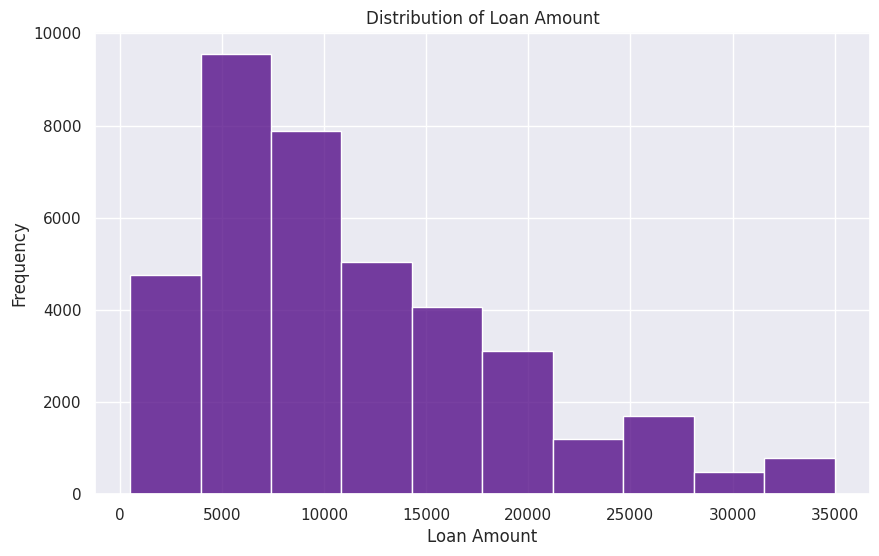


Descriptive Statistics :
 count    38576.000000
mean     11296.066855
std       7460.746022
min        500.000000
25%       5500.000000
50%      10000.000000
75%      15000.000000
max      35000.000000
Name: loan_amount, dtype: float64


In [23]:
# Univariate analysis - Loan Status chart
plt.figure(figsize=(10, 6))

sns.histplot(df['loan_amount'], bins=10, color="Indigo")

plt.title('Distribution of Loan Amount')

plt.xlabel('Loan Amount')

plt.ylabel('Frequency')

plt.show()

print("\nDescriptive Statistics :\n",df.loan_amount.describe())

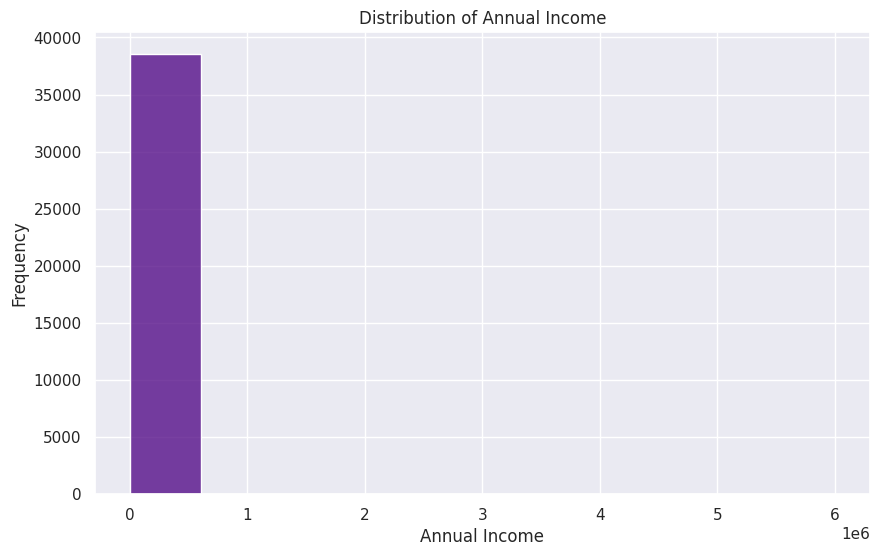


Descriptive Statistics :
 count    3.857600e+04
mean     6.964454e+04
std      6.429368e+04
min      4.000000e+03
25%      4.150000e+04
50%      6.000000e+04
75%      8.320050e+04
max      6.000000e+06
Name: annual_income, dtype: float64


In [24]:
#Annual Income
plt.figure(figsize=(10, 6))

sns.histplot(df['annual_income'], bins=10, color="Indigo")

plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')

plt.show()

print("\nDescriptive Statistics :\n", df.annual_income.describe())

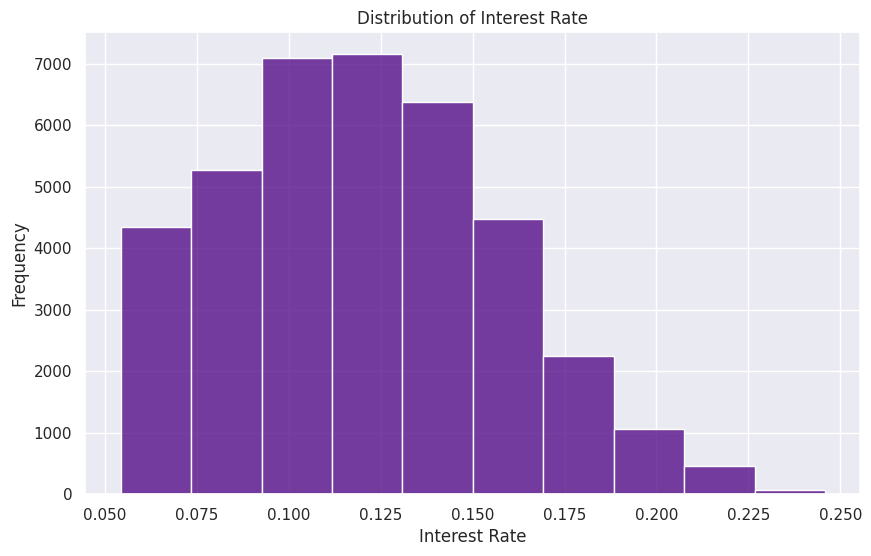


Descriptive Statistics :
 count    38576.000000
mean         0.120488
std          0.037164
min          0.054200
25%          0.093200
50%          0.118600
75%          0.145900
max          0.245900
Name: int_rate, dtype: float64


In [25]:
#Univariate Analysis — Interest Rate
plt.figure(figsize=(10, 6))

sns.histplot(df['int_rate'], bins=10, color="Indigo")

plt.title('Distribution of Interest Rate')
plt.xlabel('Interest Rate')
plt.ylabel('Frequency')

plt.show()

print("\nDescriptive Statistics :\n", df.int_rate.describe())

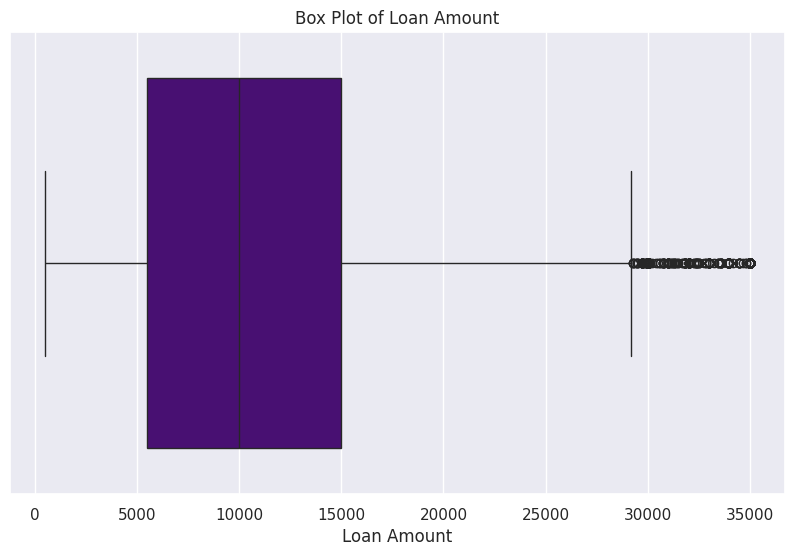

In [26]:
#Box Plot Analysis
plt.figure(figsize=(10, 6))

sns.boxplot(x=df['loan_amount'], color="Indigo")

plt.title('Box Plot of Loan Amount')
plt.xlabel('Loan Amount')

plt.show()

In [27]:
#bivariate Analysis
#Calculate default rate by Grade
grade_default = df.groupby('grade')['default_flag'].mean() * 100

print(grade_default)

grade
A     5.697182
B    11.504197
C    16.017206
D    20.686993
E    24.802584
F    30.252918
G    31.309904
Name: default_flag, dtype: float64


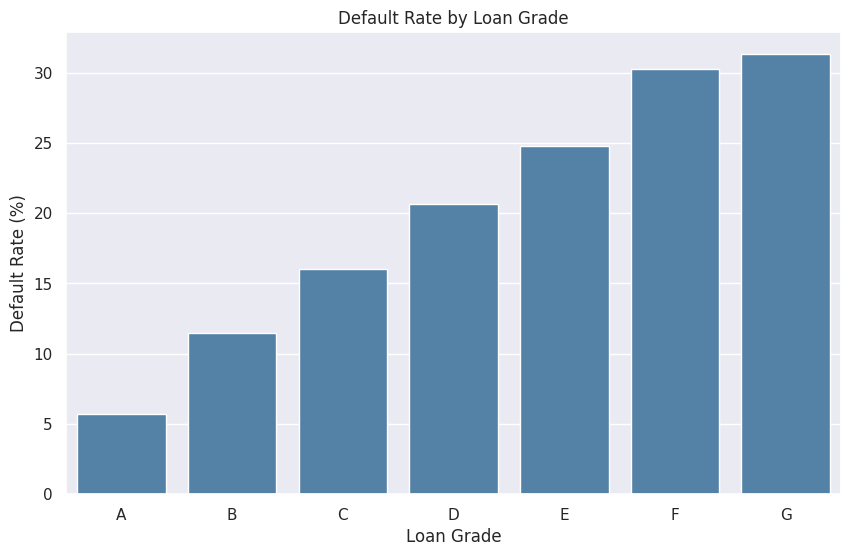

In [28]:
plt.figure(figsize=(10, 6))

sns.barplot(x=grade_default.index, y=grade_default.values, color="steelblue")

plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')

plt.show()

In [29]:
loan_default = df.groupby('default_flag')['loan_amount'].mean()

print(loan_default)

default_flag
0    11136.926571
1    12288.060191
Name: loan_amount, dtype: float64


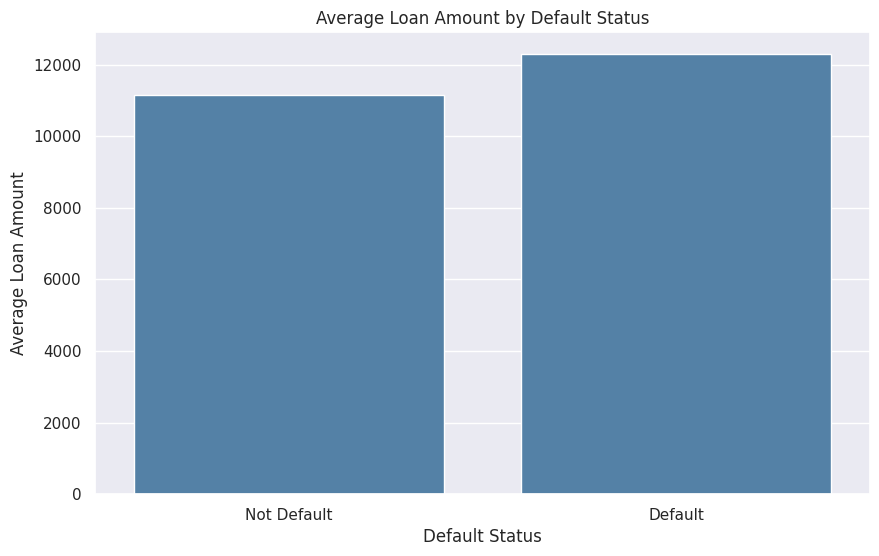

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=loan_default.index,
    y=loan_default.values,
    color="steelblue"
)

plt.title('Average Loan Amount by Default Status')
plt.xlabel('Default Status')
plt.ylabel('Average Loan Amount')

plt.xticks([0, 1], ['Not Default', 'Default'])

plt.show()

In [31]:
#interest Rate vs Default Status
interest_default = df.groupby('default_flag')['int_rate'].mean() * 100

print(interest_default)

default_flag
0    11.755295
1    13.878575
Name: int_rate, dtype: float64


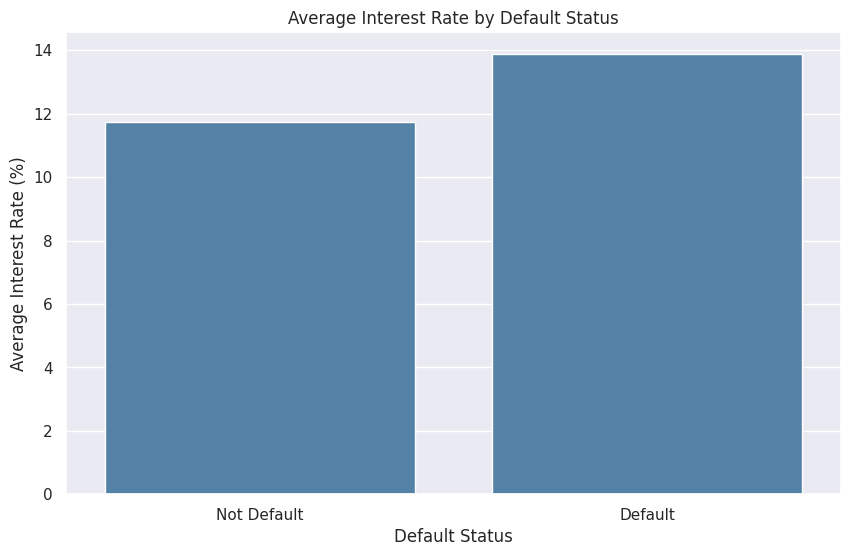

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=interest_default.index,
    y=interest_default.values,
    color="steelblue"
)

plt.title('Average Interest Rate by Default Status')
plt.xlabel('Default Status')
plt.ylabel('Average Interest Rate (%)')

plt.xticks([0, 1], ['Not Default', 'Default'])

plt.show()

In [33]:
# Final Summary - EDA

print("\nEDA Summary:- \n")

print("-> Univariate Analysis: Examined individual variables such as Loan Status, Loan Amount, Annual Income, and Interest Rate to understand their distributions and identify potential outliers.")

print("-> Bivariate Analysis: Explored relationships between Loan Grade, Loan Amount, Interest Rate, and Default Status to understand factors associated with loan defaults.")

print("-> Key Insights: Identified that default rates increase from Grade A to Grade G, while defaulted loans have higher average loan amounts and interest rates compared with non-defaulted loans.")

print("-> Overall Finding: Loan Grade and Interest Rate show noticeable differences between defaulted and non-defaulted loans, providing useful insights into loan risk patterns.")

print("\nEDA Completed.")


EDA Summary:- 

-> Univariate Analysis: Examined individual variables such as Loan Status, Loan Amount, Annual Income, and Interest Rate to understand their distributions and identify potential outliers.
-> Bivariate Analysis: Explored relationships between Loan Grade, Loan Amount, Interest Rate, and Default Status to understand factors associated with loan defaults.
-> Key Insights: Identified that default rates increase from Grade A to Grade G, while defaulted loans have higher average loan amounts and interest rates compared with non-defaulted loans.
-> Overall Finding: Loan Grade and Interest Rate show noticeable differences between defaulted and non-defaulted loans, providing useful insights into loan risk patterns.

EDA Completed.


Grade A: 5.70% default rate
Grade G: 31.31% default rate
Average loan amount: ₹11,296
Defaulted loans average loan amount: ₹12,288
Non-defaulted loans average loan amount: ₹11,137
Defaulted loans average interest rate: 13.88%
Non-defaulted loans average interest rate: 11.76%
Annual income showed high-value outliers, with a maximum of ₹60 lakh.